# Import thư viện


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Đọc dữ liệu


In [94]:
df = pd.read_csv("../data/images/fashion-mnist_test.csv")

y = df['label'].values
X = df.drop('label',axis=1).values

X = X.reshape(-1,28,28).astype(np.uint8)

print("Image shape: ",X.shape)

Image shape:  (10000, 28, 28)


# Hiển thị ảnh gốc và các kích thước dự tính reshape

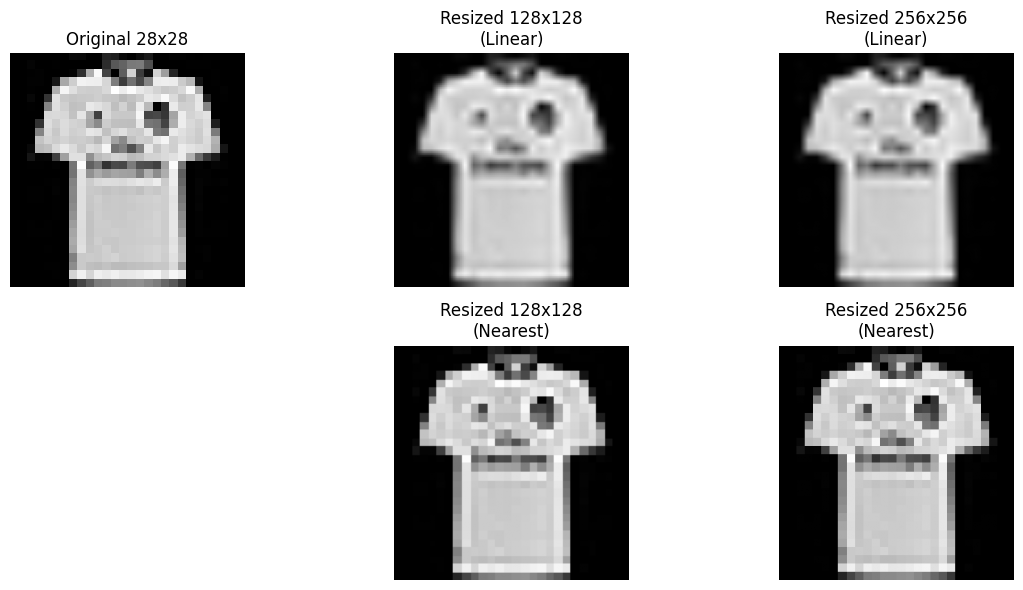

In [95]:
img = X[0]

resized128_linear = cv2.resize(img, (128,128), interpolation=cv2.INTER_LINEAR)
resized128_nearest = cv2.resize(img, (128,128), interpolation=cv2.INTER_NEAREST)
resized256_linear = cv2.resize(img, (256,256), interpolation=cv2.INTER_LINEAR)
resized256_nearest = cv2.resize(img, (256,256), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.title("Original 28x28")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Resized 128x128\n(Linear)")
plt.imshow(resized128_linear, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Resized 256x256\n(Linear)")
plt.imshow(resized256_linear, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Resized 128x128\n(Nearest)")
plt.imshow(resized128_nearest, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Resized 256x256\n(Nearest)")
plt.imshow(resized256_nearest, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


Nhận xét: Thay đổi kích thước từ ảnh 28x28 lên kích thước 128x128 và 256x256 bằng phương pháp nội suy INTER_LINEAR sẽ cho thấy ảnh ra rõ nét hơn so với phương pháp INTER_NEAREST và kích thước 128x128 so với 256x256 không có sự khác biệt quá nhiều nên ở đây em sẽ chọn phương pháp nội suy INTER_LINEAR so với INTER_NEARST.

# Chuyển đổi ảnh xám
Vì tập dữ liệu này chỉ là ảnh xám nên ở bước này em chỉ đưa ra các thảo luận
- So sánh về khả năng lưu trữ thông tin: Nếu là ảnh màu thì có vẻ sẽ thêm được thông tin về màu sắc của vật thể tuy nhiên chỉ để ảnh xám vẫn giữ được thông tin chính để có thể phân biệt giữa các vật thể nên cũng không quá quan trọng có màu, có thể giảm phần lớn về chi phí tính toán
- Khi nào nên chuyển đổi thành ảnh gray: khi bài toán là shape/edge/texture, tập dataset lớn cần xử lí nhanh hơn. Ví dụ một số bài toán như: Chữ viết tay, X-Ray và trong bài toán Fashion-MNIST này cũng chỉ cần ảnh xám là đủ
- Khi nào không nên chuyển đổi thành ảnh gray: Nếu màu là feature chính, nhận dạng vật thể theo màu. Ví dụ như: nhận diện trái cây, phân loại hoa,...

# Chuẩn hóa pixel

In [96]:
img = resized128_linear.astype(np.float32)

min_value = img.min()
max_value = img.max()

print("Giá trị pixel min/max là: ",min_value,max_value)

## Chuẩn hóa min-max [0,1]

img_01 = (img - min_value) / (max_value - min_value)

## Chuẩn hóa min-max [-1,1]
img_m11 = 2 * img_01 - 1

mean = img.mean()
std = img.std()

img_std = (img - mean) / std

print("Khoảng chuẩn hóa [0,1]: ", img_01.min(),img_01.max())
print("Khoảng chuẩn hóa [-1,1]: ", img_m11.min(),img_m11.max())
print("Chuẩn hóa mean/std: ",img_std.mean(),img_std.std())


Giá trị pixel min/max là:  0.0 251.0
Khoảng chuẩn hóa [0,1]:  0.0 1.0
Khoảng chuẩn hóa [-1,1]:  -1.0 1.0
Chuẩn hóa mean/std:  1.1175871e-08 1.0000001


# So sánh ảnh trực quan sau chuẩn hóa

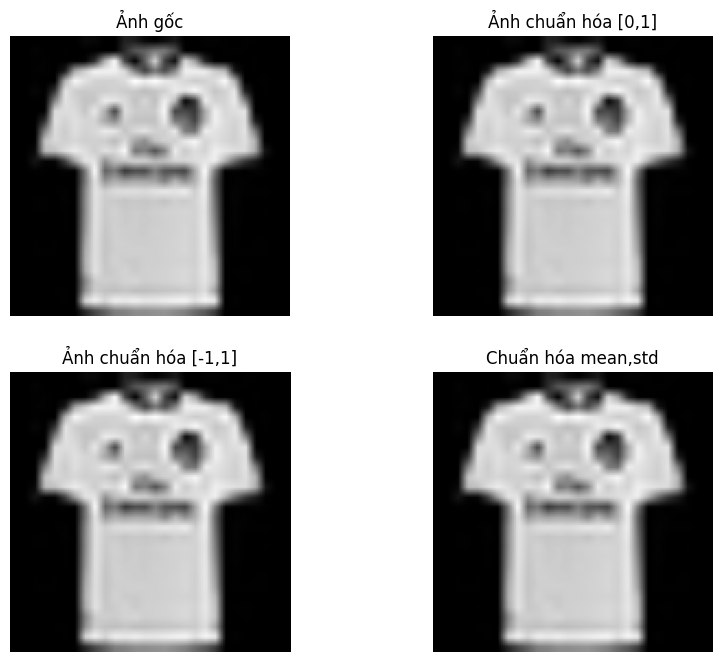

In [97]:

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img,cmap='gray')
plt.title("Ảnh gốc")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_01,cmap='gray')
plt.title("Ảnh chuẩn hóa [0,1]")
plt.axis('off');

plt.subplot(2,2,3)
plt.imshow(img_m11,cmap='gray')
plt.title("Ảnh chuẩn hóa [-1,1]")
plt.axis('off');

plt.subplot(2,2,4)
plt.imshow(img_std,cmap='gray')
plt.title("Chuẩn hóa mean,std")
plt.axis('off');

Nhận xét: Qua so sánh trực quan, tất cả các hình ảnh đã được chuẩn hóa đều gần như giống hệt hình ảnh gốc. Điều này là điều dễ hiểu vì các kỹ thuật chuẩn hóa như chia tỷ lệ min-max và chuẩn hóa là các phép biến đổi tuyến tính chỉ thay đổi thang đo số của giá trị pixel mà không làm thay đổi cấu trúc không gian hoặc mối quan hệ cường độ tương đối.

# So sảnh phân phối histogram

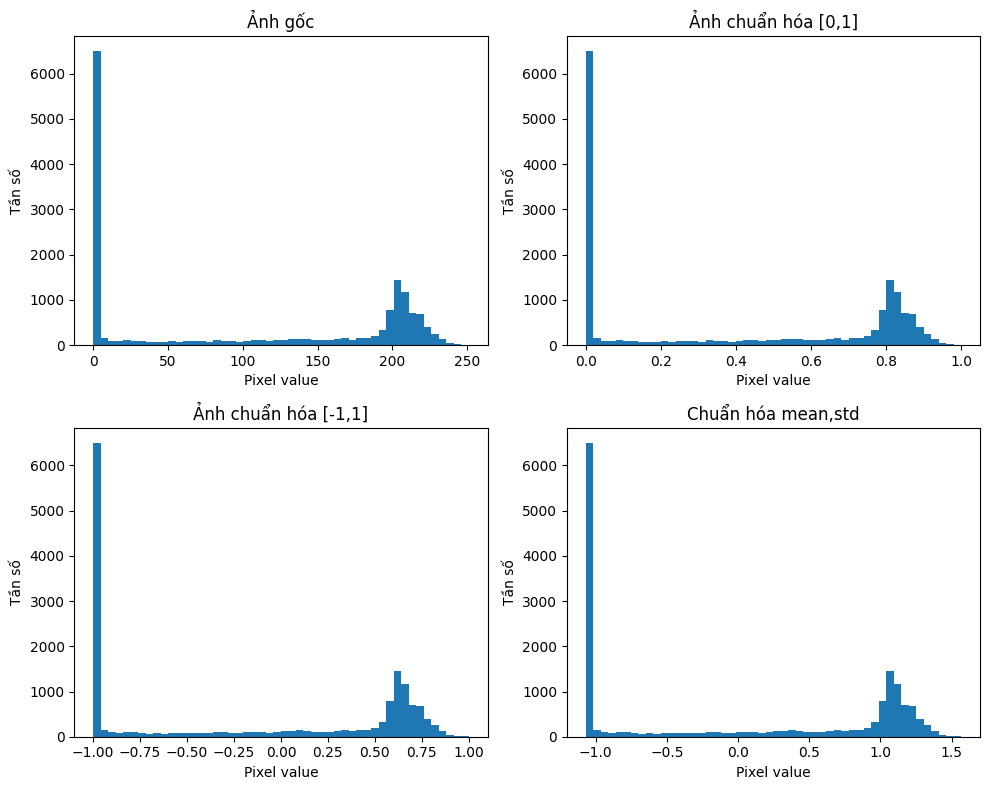

In [98]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.hist(img.flatten(), bins=50)
plt.title("Ảnh gốc")
plt.xlabel("Pixel value")
plt.ylabel("Tần số")

plt.subplot(2,2,2)
plt.hist(img_01.flatten(), bins=50)
plt.title("Ảnh chuẩn hóa [0,1]")
plt.xlabel("Pixel value")
plt.ylabel("Tần số")

plt.subplot(2,2,3)
plt.hist(img_m11.flatten(), bins=50)
plt.title("Ảnh chuẩn hóa [-1,1]")
plt.xlabel("Pixel value")
plt.ylabel("Tần số")

plt.subplot(2,2,4)
plt.hist(img_std.flatten(), bins=50)
plt.title("Chuẩn hóa mean,std")
plt.xlabel("Pixel value")
plt.ylabel("Tần số")

plt.tight_layout()
plt.show()


Quan sát histogram cho thấy tất cả các phương pháp chuẩn hóa đều giữ nguyên hình dạng phân phối. Điều này là do các phương pháp như min–max scaling và standardization chỉ là các phép biến đổi tuyến tính, chỉ thay đổi thang đo hoặc dịch chuyển giá trị pixel mà không làm thay đổi mối quan hệ tương đối giữa các pixel.

Min–max normalization nén dữ liệu vào khoảng [0,1] hoặc [-1,1], giúp giảm độ lớn giá trị và tăng tính ổn định số khi huấn luyện mô hình. Trong khi đó, standardization đưa dữ liệu về trung bình 0 và độ lệch chuẩn 1, tạo phân phối tập trung quanh 0, giúp các thuật toán học máy hội tụ nhanh hơn.

Mặc dù ảnh sau chuẩn hóa nhìn gần như không thay đổi, nhưng các đặc tính thống kê của dữ liệu đã được cải thiện đáng kể, từ đó hỗ trợ quá trình huấn luyện hiệu quả hơn.

# Trích xuất cạnh bằng Sobel

In [99]:
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize = 3)
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize = 3)

sobel = np.sqrt(sobelx**2 + sobely**2)
sobel = np.clip(sobel,0,255)
sobel = np.uint8(sobel)




# Trích xuất cạnh bằng Prewitt

In [100]:
kernelx = np.array([ [1,0,-1],
                    [1,0,-1],
                    [1,0,-1]])

kernely = np.array([ [1,1,1],
                    [0,0,0],
                    [-1,-1,-1]])

prewittx = cv2.filter2D(img,-1 , kernelx)
prewitty = cv2.filter2D(img, -1, kernely)

prewitt = np.sqrt(prewittx**2 + prewitty**2)
prewitt = np.clip(prewitt,0,255)
prewitt = np.uint8(prewitt)


# Trích xuất cạnh bằng Canny

In [101]:
canny = cv2.Canny(img.astype(np.uint8), threshold1=50, threshold2=150)

Lý do chọn threshold1 là 50 và threshold2 bằng 150 vì trong tài liệu OpenCV khuyến khích chọn tỉ lệ upper:lower 2:1 hoặc 3:1.

Tham khảo: [Canny Edge Detection - OpenCV](https://docs.opencv.org/4.x/da/d5c/tutorial_canny_detector.html)

# Trực quan các ảnh đã trích xuất cạnh theo các thuật toán khác nhau

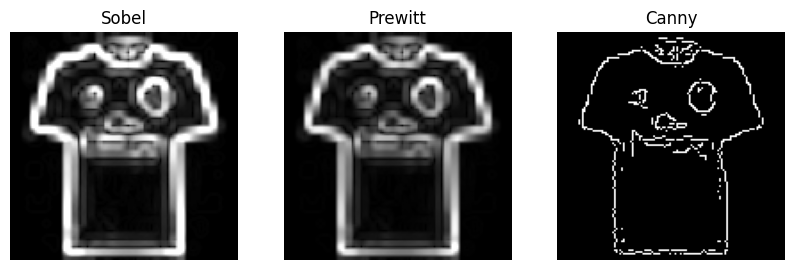

In [102]:
plt.figure(figsize=(10,8))


plt.subplot(1,3,1)
plt.imshow(sobel,cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(prewitt,cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(canny,cmap='gray')
plt.title("Canny")
plt.axis('off');



Nhận xét
- Đối với thuật toán Sobel thì trích xuất biên khá dày,sáng mạnh quanh biên áo và còn nhiều texture bên trong áo, không tốt cho trích biên rõ ràng
- Đối với thuật toán Prewitt thì giống sobel nhưng cạnh mờ hơi và biên mỏng hơn sobel tuy nhiên vẫn trích biên vẫn không tốt và rõ ràng
- Đối với thuật toán Canny cho kết quả trích xuất cạnh tốt nhất vì tạo ra biên mỏng nhất, rõ ràng và ít nhiễu bên trong.

--> Đối với tập dữ liệu Fashion-MNIST thì hình dạng là đặc trưng quan trọng nhất, nên sử dụng thuật toán Canny để trích xuất chính xác đường viền quần áo do đó có thể tạo ra đặc trưng tốt để phân loại đối với dataset này